# Param Shah
## 240905320
## CSE-D 33
### Lab 6: Cost Functions

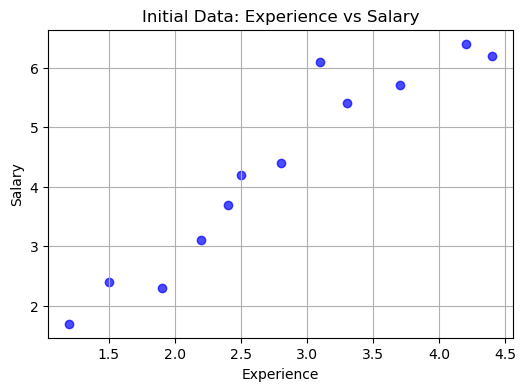

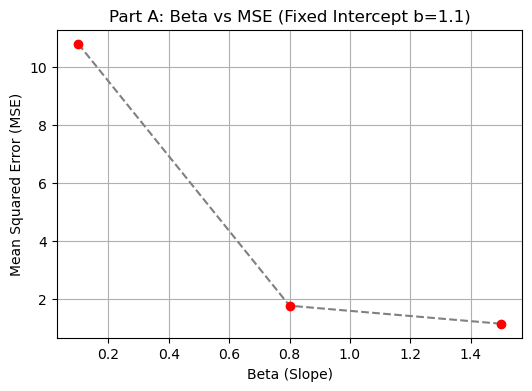

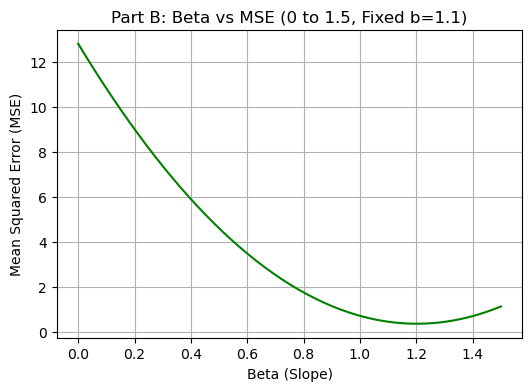

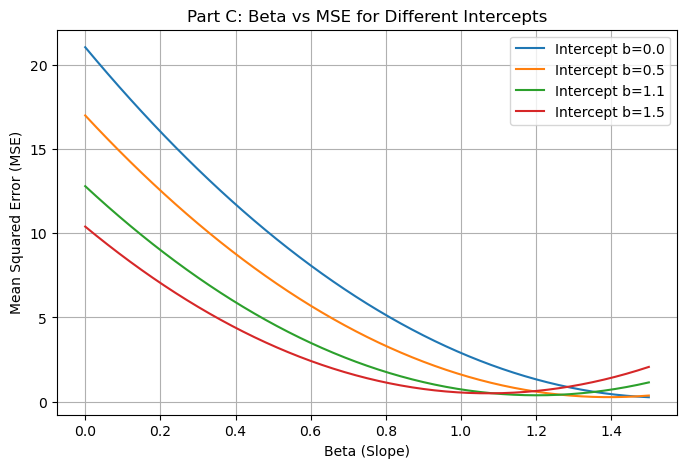

--- Scikit-Learn Results ---
Optimal Beta (Slope): 1.5671
Optimal Intercept: -0.0356
Minimum MSE: 0.2337

--- Manual Search Results (from Part B where b=1.1) ---
Lowest MSE found: 0.3753 (at beta = 1.20)

Comparison: Scikit-learn achieves a lower MSE by optimizing both the slope and the intercept simultaneously, rather than keeping the intercept fixed at 1.1.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

data = {
    'experience': [1.2, 1.5, 1.9, 2.2, 2.4, 2.5, 2.8, 3.1, 3.3, 3.7, 4.2, 4.4],
    'salary': [1.7, 2.4, 2.3, 3.1, 3.7, 4.2, 4.4, 6.1, 5.4, 5.7, 6.4, 6.2]
}
df = pd.DataFrame(data)
df.to_csv('experience_salary.csv', index=False)

plt.figure(figsize=(6, 4))
plt.scatter(df['experience'], df['salary'], color='blue', alpha=0.7)
plt.xlabel('Experience')
plt.ylabel('Salary')
plt.title('Initial Data: Experience vs Salary')
plt.grid(True)
plt.show()

def calculate_mse(beta, b, x, y):
    y_pred = beta * x + b
    return np.mean((y - y_pred) ** 2)

x = df['experience']
y = df['salary']

# a. Check for various values of beta = 0.1, 1.5, and 0.8 with b = 1.1
betas_a = [0.1, 0.8, 1.5]
b_fixed = 1.1
mses_a = [calculate_mse(beta, b_fixed, x, y) for beta in betas_a]

plt.figure(figsize=(6, 4))
plt.scatter(betas_a, mses_a, color='red', zorder=5)
plt.plot(betas_a, mses_a, linestyle='--', color='gray')
plt.xlabel('Beta (Slope)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Part A: Beta vs MSE (Fixed Intercept b=1.1)')
plt.grid(True)
plt.show()

# b. Try with beta between 0 to 1.5 with an increment of 0.01 keeping b=1.1
betas_b = np.arange(0, 1.51, 0.01)
mses_b = [calculate_mse(beta, b_fixed, x, y) for beta in betas_b]

plt.figure(figsize=(6, 4))
plt.plot(betas_b, mses_b, color='green')
plt.xlabel('Beta (Slope)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Part B: Beta vs MSE (0 to 1.5, Fixed b=1.1)')
plt.grid(True)
plt.show()

# c. Try with different values of intercept for slope beta between 0 to 1.5
intercepts = [0.0, 0.5, 1.1, 1.5]

plt.figure(figsize=(8, 5))
for b_val in intercepts:
    mses_c = [calculate_mse(beta, b_val, x, y) for beta in betas_b]
    plt.plot(betas_b, mses_c, label=f'Intercept b={b_val}')

plt.xlabel('Beta (Slope)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Part C: Beta vs MSE for Different Intercepts')
plt.legend()
plt.grid(True)
plt.show()

# d. Use scikit-learn and compare the results of MSE
X_reshaped = df[['experience']] 
y_target = df['salary']

model = LinearRegression()
model.fit(X_reshaped, y_target)

beta_sk = model.coef_[0]
b_sk = model.intercept_
y_pred_sk = model.predict(X_reshaped)
mse_sk = mean_squared_error(y_target, y_pred_sk)

print("--- Scikit-Learn Results ---")
print(f"Optimal Beta (Slope): {beta_sk:.4f}")
print(f"Optimal Intercept: {b_sk:.4f}")
print(f"Minimum MSE: {mse_sk:.4f}")

# Compare to part B minimum
min_mse_b = min(mses_b)
min_beta_b = betas_b[mses_b.index(min_mse_b)]
print("\n--- Manual Search Results (from Part B where b=1.1) ---")
print(f"Lowest MSE found: {min_mse_b:.4f} (at beta = {min_beta_b:.2f})")
print("\nComparison: Scikit-learn achieves a lower MSE by optimizing both the slope and the intercept simultaneously, rather than keeping the intercept fixed at 1.1.")

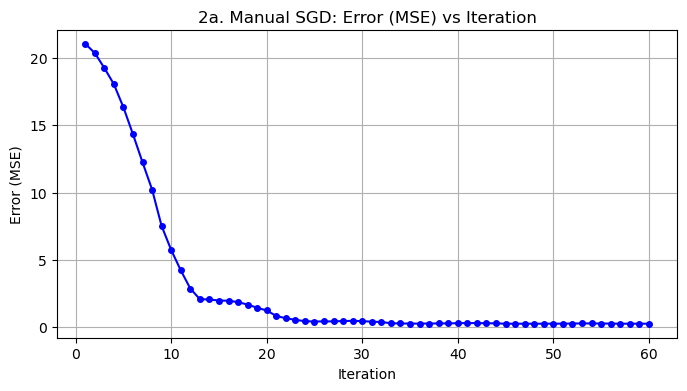

In [12]:
epochs = 5
learning_rate = 0.01
b0, b1 = 0.0, 0.0

manual_b1_list = []
manual_error_list = []
iteration_list = []

# Manual Stochastic Gradient Descent
iteration = 1
for epoch in range(epochs):
    for i in range(len(x)):
        y_pred_all = b0 + b1 * x
        mse = np.mean((y_pred_all - y) ** 2)
        
        manual_b1_list.append(b1)
        manual_error_list.append(mse)
        iteration_list.append(iteration)
        
        y_pred_sample = b0 + b1 * x[i]
        error_term = y_pred_sample - y[i]
        
        b0 = b0 - learning_rate * error_term
        b1 = b1 - learning_rate * error_term * x[i]
        
        iteration += 1

plt.figure(figsize=(8, 4))
plt.plot(iteration_list, manual_error_list, marker='o', color='blue', markersize=4)
plt.title("2a. Manual SGD: Error (MSE) vs Iteration")
plt.xlabel("Iteration")
plt.ylabel("Error (MSE)")
plt.grid(True)
plt.show()

In [13]:
from sklearn.linear_model import SGDRegressor

X_reshaped = np.array(x).reshape(-1, 1)

sgd_model = SGDRegressor(learning_rate='constant', eta0=0.01, penalty=None, random_state=4234)

sk_b1_list = []
sk_error_list = []
sk_iteration = 1

for epoch in range(epochs):
    for i in range(len(x)):
        if hasattr(sgd_model, 'coef_'):
            current_b1 = sgd_model.coef_[0]
            current_mse = mean_squared_error(y, sgd_model.predict(X_reshaped))
        else:
            current_b1 = 0.0
            current_mse = np.mean((y - 0.0)**2)
            
        sk_b1_list.append(current_b1)
        sk_error_list.append(current_mse)
        
        X_sample = X_reshaped[i].reshape(1, -1)
        y_sample = np.array([y[i]])
        sgd_model.partial_fit(X_sample, y_sample)
        sk_iteration += 1

print("--- 2b. Scikit-Learn SGD Final Results ---")
print(f"Final B0 (Intercept): {sgd_model.intercept_[0]:.4f}")
print(f"Final B1 (Slope): {sgd_model.coef_[0]:.4f}")
print(f"Final Error (MSE): {mean_squared_error(y, sgd_model.predict(X_reshaped)):.4f}\n")

--- 2b. Scikit-Learn SGD Final Results ---
Final B0 (Intercept): 0.4750
Final B1 (Slope): 1.3938
Final Error (MSE): 0.2630



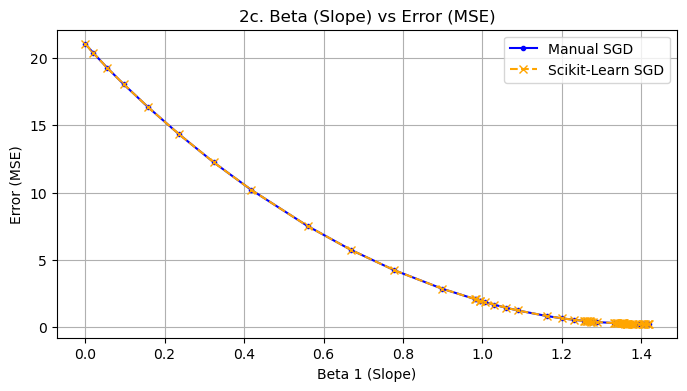

In [15]:
plt.figure(figsize=(8, 4))
plt.plot(manual_b1_list, manual_error_list, label='Manual SGD', color='blue', marker='.')
plt.plot(sk_b1_list, sk_error_list, label='Scikit-Learn SGD', color='orange', marker='x', linestyle='--')
plt.title("2c. Beta (Slope) vs Error (MSE)")
plt.xlabel("Beta 1 (Slope)")
plt.ylabel("Error (MSE)")
plt.legend()
plt.grid(True)
plt.show()

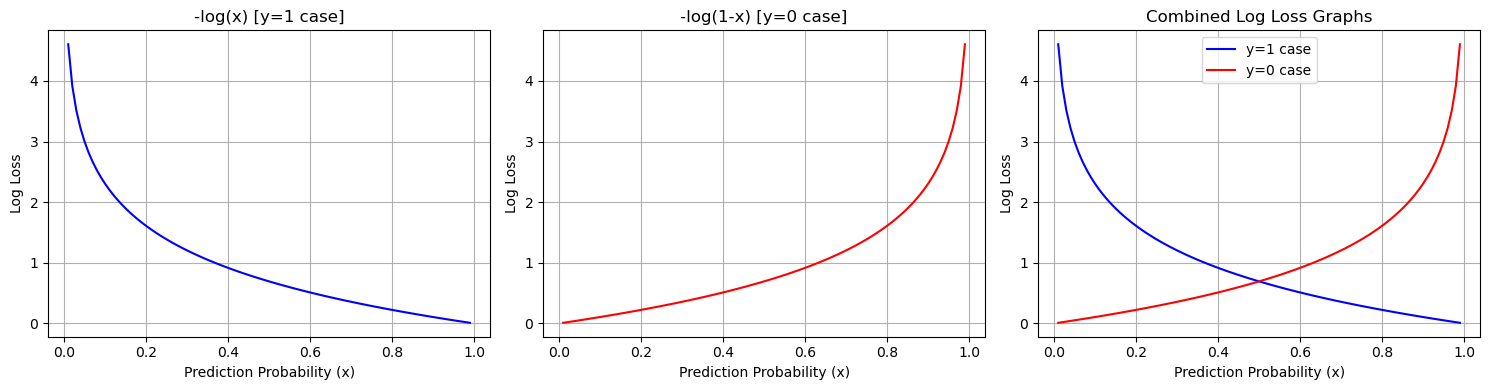

In [16]:
p = np.linspace(0.01, 0.99, 100) 
loss_y1 = -np.log(p)            
loss_y0 = -np.log(1 - p)       

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

# Graph for y=1 case
ax1.plot(p, loss_y1, color='blue')
ax1.set_title("-log(x) [y=1 case]")
ax1.set_xlabel("Prediction Probability (x)")
ax1.set_ylabel("Log Loss")
ax1.grid(True)

# Graph for y=0 case
ax2.plot(p, loss_y0, color='red')
ax2.set_title("-log(1-x) [y=0 case]")
ax2.set_xlabel("Prediction Probability (x)")
ax2.set_ylabel("Log Loss")
ax2.grid(True)

# Combined Graph
ax3.plot(p, loss_y1, color='blue', label='y=1 case')
ax3.plot(p, loss_y0, color='red', label='y=0 case')
ax3.set_title("Combined Log Loss Graphs")
ax3.set_xlabel("Prediction Probability (x)")
ax3.set_ylabel("Log Loss")
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
def gradient_descent(x, y, iterations=100, learning_rate=0.01):
    m = 0.0 
    c = 0.0 
    n = len(x)
    
    slopes = []
    mses = []
    
    for _ in range(iterations):
        y_pred = m * x + c
        mse = np.mean((y - y_pred) ** 2)
        
        slopes.append(m)
        mses.append(mse)
        
        dm = (-2 / n) * np.sum(x * (y - y_pred))
        dc = (-2 / n) * np.sum(y - y_pred)
        
        m = m - learning_rate * dm
        c = c - learning_rate * dc
        
    return slopes, mses

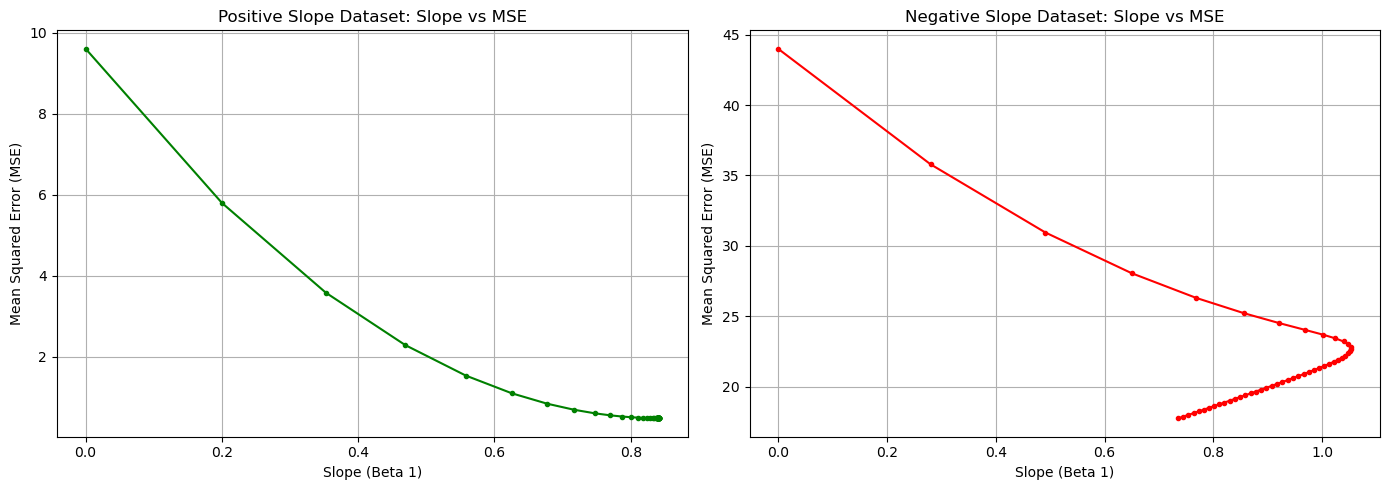

In [19]:
# Positive Slope Dataset
x_pos = np.array([1, 2, 4, 3, 5])
y_pos = np.array([1, 3, 3, 2, 5]) 

# Negative Slope Dataset
x_neg = np.array([1, 2, 3, 4, 5])
y_neg = np.array([10, 8, 6, 4, 2]) 

slopes_pos, mses_pos = gradient_descent(x_pos, y_pos, iterations=50, learning_rate=0.01)
slopes_neg, mses_neg = gradient_descent(x_neg, y_neg, iterations=50, learning_rate=0.01)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Positive Slope Plot
ax1.plot(slopes_pos, mses_pos, marker='.', color='green')
ax1.set_title('Positive Slope Dataset: Slope vs MSE')
ax1.set_xlabel('Slope (Beta 1)')
ax1.set_ylabel('Mean Squared Error (MSE)')
ax1.grid(True)

# Negative Slope Plot
ax2.plot(slopes_neg, mses_neg, marker='.', color='red')
ax2.set_title('Negative Slope Dataset: Slope vs MSE')
ax2.set_xlabel('Slope (Beta 1)')
ax2.set_ylabel('Mean Squared Error (MSE)')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [20]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_log_loss(y, y_pred):
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))

def logistic_regression_gd(x, y, iterations=1000, learning_rate=0.1):
    b0 = 0.0
    b1 = 0.0
    n = len(x)
    
    slopes = []
    losses = []
    
    for _ in range(iterations):
        z = b0 + b1 * x
        y_pred = sigmoid(z)
        
        loss = compute_log_loss(y, y_pred)
        
        slopes.append(b1)
        losses.append(loss)
        
        db0 = (1/n) * np.sum(y_pred - y)
        db1 = (1/n) * np.sum((y_pred - y) * x)
        
        b0 = b0 - learning_rate * db0
        b1 = b1 - learning_rate * db1
        
    return slopes, losses

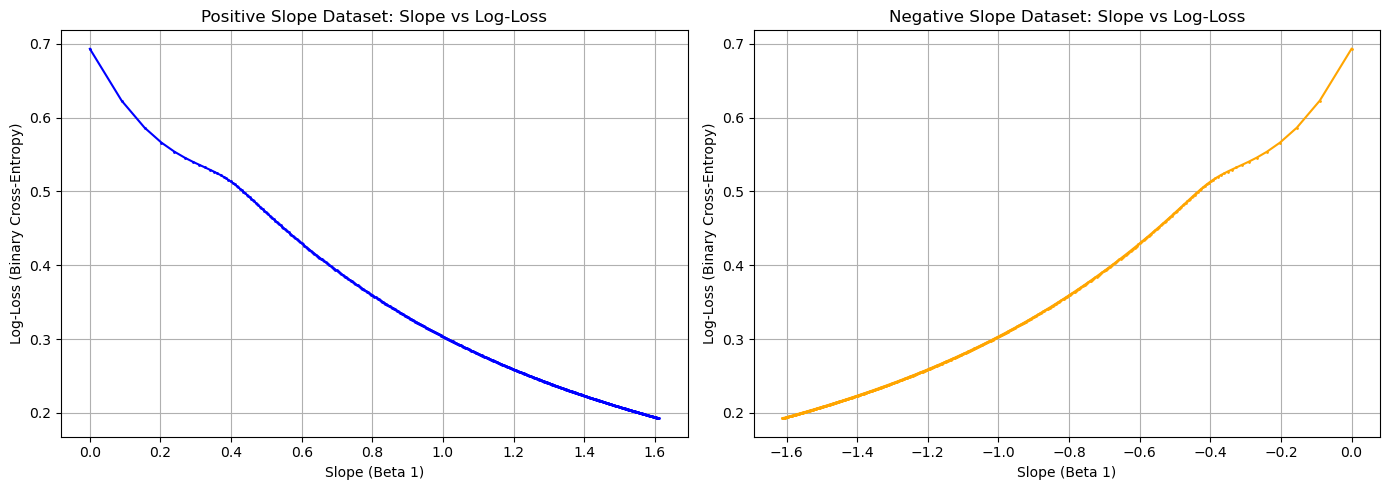

In [22]:
# Positive slope dataset
x_pos = np.array([1, 2, 3, 4, 5])
y_pos = np.array([0, 0, 1, 1, 1]) 

# Negative slope dataset
x_neg = np.array([1, 2, 3, 4, 5])
y_neg = np.array([1, 1, 0, 0, 0]) 

slopes_pos, losses_pos = logistic_regression_gd(x_pos, y_pos, iterations=500, learning_rate=0.1)
slopes_neg, losses_neg = logistic_regression_gd(x_neg, y_neg, iterations=500, learning_rate=0.1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Positive Slope Plot
ax1.plot(slopes_pos, losses_pos, marker='.', color='blue', markersize=2)
ax1.set_title('Positive Slope Dataset: Slope vs Log-Loss')
ax1.set_xlabel('Slope (Beta 1)')
ax1.set_ylabel('Log-Loss (Binary Cross-Entropy)')
ax1.grid(True)

# Negative Slope Plot
ax2.plot(slopes_neg, losses_neg, marker='.', color='orange', markersize=2)
ax2.set_title('Negative Slope Dataset: Slope vs Log-Loss')
ax2.set_xlabel('Slope (Beta 1)')
ax2.set_ylabel('Log-Loss (Binary Cross-Entropy)')
ax2.grid(True)

plt.tight_layout()
plt.show()